In [9]:
%load_ext autoreload
%autoreload 2
import sys
from rdkit import Chem
sys.path.append('src')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from src import MoleculeRenderer


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))


In [11]:
def freeze_original_index(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetProp("original_index", str(i))  # Зафриженный исходный индекс


=== Тестирование MoleculeRenderer ===


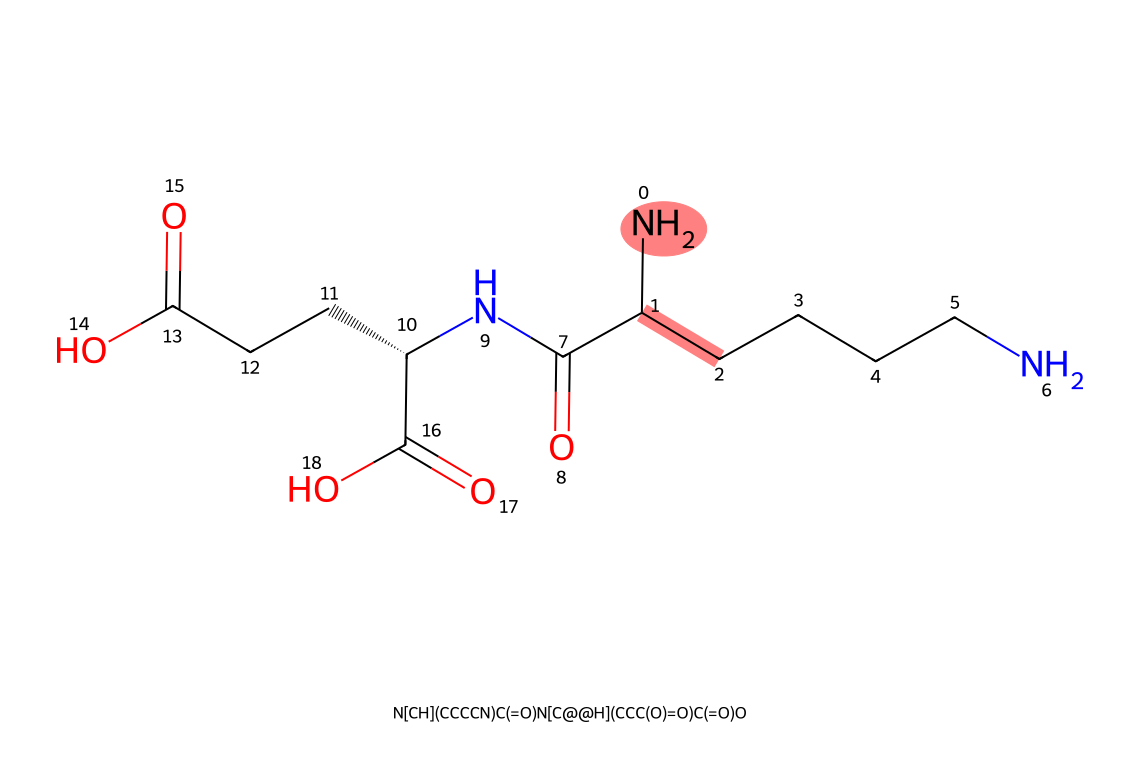

2D рендеринг выполнен


In [12]:
# Тестирование модуля visualization.molecule_renderer
print("\n=== Тестирование MoleculeRenderer ===")


def test_molecule_renderer():
    mol = 'N[CH](CCCCN)C(=O)N[C@@H](CCC(O)=O)C(=O)O'
    # calculate_original_index(mol)
    mock_molecule = Chem.MolFromSmiles(mol)
    freeze_original_index(mock_molecule)
    highlight_atoms = [0]
    highlight_bounds = [1]
    # Тест 2D рендеринга
    render_2d = draw_mol(mock_molecule, mol, highlight_atoms, highlight_bounds)
    display_props=["original_index", "connection_type", "replacement_group"]
    return render_2d


test_molecule_renderer()
print("2D рендеринг выполнен")



=== Тестирование MoleculeRenderer ===


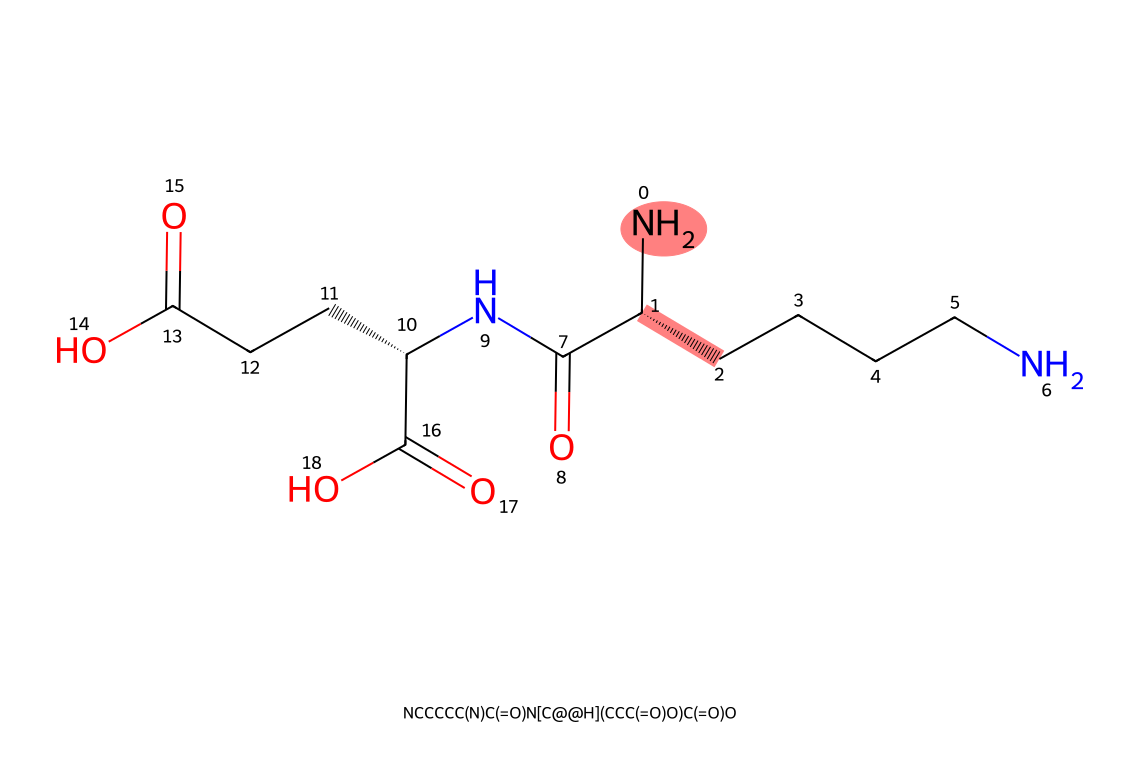

N-C-C-C-C-C(-N)-C(=O)-N-[C@@H](-C-C-C(=O)-O)-C(=O)-O
SMILES с сохраненной стереохимией:
[NH2][CH2][CH2][CH2][CH2][CH]([NH2])[C](=[O])[NH][CH]([CH2][CH2][C](=[O])[OH])[C](=[O])[OH]


AttributeError: module 'rdkit.Chem' has no attribute 'Molt'

In [13]:
# Тестирование модуля visualization.molecule_renderer
print("\n=== Тестирование MoleculeRenderer ===")
from rdkit.Chem import BondStereo, BondType


def test_molecule_renderer():
    mol = 'N[CH](CCCCN)C(=O)N[C@@H](CCC(O)=O)C(=O)O'
    # calculate_original_index(mol)
    mock_molecule = Chem.MolFromSmiles(mol)
    freeze_original_index(mock_molecule)

    highlight_atoms = [0]
    highlight_bounds = [1]

    # Получаем связь по индексу
    bond = mock_molecule.GetBondWithIdx(1)  # Получаем связь с индексом 1

    # Изменяем тип связи на "объемную" (стержневую)
    bond.SetBondType(BondType.SINGLE)  # Обычная одинарная связь
    # ИЛИ для стереохимии:
    bond.SetStereo(BondStereo.STEREOANY)  # Стереохимия "любая"

    # Для штриховой связи (от наблюдателя):
    bond.SetBondDir(Chem.rdchem.BondDir.BEGINDASH)


    # Тест 2D рендеринга
    render_2d = draw_mol(mol=mock_molecule, title="",highlight_atoms=highlight_atoms, highlight_bonds= highlight_bounds)
    display_props=["original_index", "connection_type", "replacement_group"]
    print(Chem.MolToSmiles(mock_molecule,allBondsExplicit=True))
 # Принудительно сохраняем стереохимию
    smiles_options = Chem.SmilesWriteParams()
    smiles_options.allBondsExplicit = False
    smiles_options.allHsExplicit = True
    smiles_options.doIsomericSmiles = False

    smiles_with_stereo = Chem.MolToSmiles(mock_molecule, smiles_options)
    print("SMILES с сохраненной стереохимией:")
    print(smiles_with_stereo)

    # Генерируем CXSMILES который сохраняет больше информации

    cx_smiles = Chem.Molt(mock_molecule)
    cx_smiles = Chem.MolToCXSmiles(mock_molecule)
    print("CXSMILES (сохраняет свойства):")
    print(cx_smiles)
    print("rdmolfiles (сохраняет свойства):")
    print(Chem.rdmolfiles.MolToSmiles(mock_molecule))

    return render_2d


test_molecule_renderer()
print("2D рендеринг выполнен")


In [ ]:
from typing import Dict, List, Set, Tuple, Optional
from dataclasses import dataclass
from enum import Enum

class BondType(Enum):
    SINGLE = 1
    DOUBLE = 2
    TRIPLE = 3
    AROMATIC = 4

class AtomStereo(Enum):
    R = "R"
    S = "S"
    D = "D"
    L = "L"
    M = "M"

class BondStereo(Enum):
    E = "E"
    Z = "Z"
    CIS = "c"
    TRANS = "t"

@dataclass
class Atom:
    element: str
    hydrogens: int = 0
    charge: int = 0
    isotope: Optional[int] = None
    stereo: Optional[AtomStereo] = None
    radical: Optional[str] = None
    aromatic: bool = False
    atom_map: Optional[int] = None

@dataclass
class Bond:
    bond_type: BondType
    stereo: Optional[BondStereo] = None
    reaction_center: bool = False

class SLNConverter:
    def __init__(self, debug: bool = False):
        self.ring_closure_map: Dict[Tuple[int, int], int] = {}
        self.ring_ids: Dict[int, int] = {}  # atom_idx -> ring_id
        self.next_ring_id = 1
        self.visited_atoms: Set[int] = set()
        self.atom_outputs: Dict[int, str] = {}
        self.debug = debug
        self.indent_level = 0

    def _log(self, message: str):
        if self.debug:
            indent = "  " * self.indent_level
            print(f"{indent}{message}")


    def convert_molecule(self, atoms: List[Atom], bonds: Dict[Tuple[int, int], Bond]) -> str:
        self._log(f"=== CONVERTING MOLECULE ===")
        self._log(f"Atoms: {len(atoms)}, Bonds: {len(bonds)}")

        self.ring_closure_map.clear()
        self.ring_ids.clear()
        self.next_ring_id = 1
        self.visited_atoms.clear()
        self.atom_outputs.clear()

        if not atoms:
            return ""

        # Идентифицируем кольца и назначаем ring IDs
        self._identify_rings_and_assign_ids(atoms, bonds)

        result = self._build_sln_from_atom(0, atoms, bonds)
        self._log(f"FINAL RESULT: {result}")
        return result



    def _build_graph(self, bonds: Dict[Tuple[int, int], Bond]) -> Dict[int, List[int]]:
        """Build adjacency graph from bonds"""
        graph = {}
        for (a1, a2), bond in bonds.items():
            if a1 not in graph:
                graph[a1] = []
            if a2 not in graph:
                graph[a2] = []
            graph[a1].append(a2)
            graph[a2].append(a1)
        return graph


    def _identify_rings_and_assign_ids(self, atoms: List[Atom], bonds: Dict[Tuple[int, int], Bond]):
        """Идентифицируем кольца и назначаем ring IDs атомам"""
        graph = self._build_graph(bonds)
        visited = set()
        parent_map = {}
        back_edges = []

        # DFS для нахождения back edges (кольцевых связей)
        stack = [(0, -1)]
        while stack:
            current, parent = stack.pop()
            if current not in visited:
                visited.add(current)
                parent_map[current] = parent
                for neighbor in graph.get(current, []):
                    if neighbor == parent:
                        continue
                    if neighbor in visited:
                        # Нашли back edge - это кольцевая связь
                        back_edges.append(tuple(sorted([current, neighbor])))
                    else:
                        stack.append((neighbor, current))

        # Для каждого кольца назначаем ring ID первому атому в back edge
        for u, v in back_edges:
            ring_start = min(u, v)
            if ring_start not in self.ring_ids:
                self.ring_ids[ring_start] = self.next_ring_id
                self._log(f"Assigned ring ID {self.next_ring_id} to atom {ring_start}")
                self.next_ring_id += 1

    def _build_sln_from_atom(self, atom_idx: int, atoms: List[Atom],
                           bonds: Dict[Tuple[int, int], Bond]) -> str:
        if atom_idx in self.visited_atoms:
            self._log(f"Atom {atom_idx} already visited, returning empty")
            return ""

        self.visited_atoms.add(atom_idx)
        atom = atoms[atom_idx]

        self._log(f"Processing atom {atom_idx}: {atom.element} with {atom.hydrogens} hydrogens")
        self.indent_level += 1

        atom_sln = self._format_atom(atom, atom_idx)
        self._log(f"Formatted atom: '{atom_sln}'")

        neighbors = self._get_neighbors(atom_idx, bonds)
        self._log(f"Neighbors: {[n[0] for n in neighbors]}")

        if not neighbors:
            self.indent_level -= 1
            return atom_sln

        sln_parts = [atom_sln]
        first_neighbor = True

        for neighbor_idx, bond in neighbors:
            self._log(f"Processing neighbor {neighbor_idx} with bond {bond.bond_type}")

            if neighbor_idx in self.visited_atoms:
                ring_closure = self._handle_ring_closure(atom_idx, neighbor_idx, bond)
                if ring_closure:
                    self._log(f"Ring closure from {atom_idx} to {neighbor_idx}: '{ring_closure}'")
                    sln_parts.append(ring_closure)
                continue

            bond_sln = self._format_bond(bond)
            self._log(f"Bond from {atom_idx} to {neighbor_idx}: '{bond_sln}'")

            if first_neighbor:
                neighbor_sln = self._build_sln_from_atom(neighbor_idx, atoms, bonds)
                sln_parts.append(bond_sln)
                sln_parts.append(neighbor_sln)
                self._log(f"First neighbor result: '{bond_sln + neighbor_sln}'")
                first_neighbor = False
            else:
                neighbor_sln = self._build_sln_from_atom(neighbor_idx, atoms, bonds)
                branch_content = bond_sln + neighbor_sln
                branch_with_parens = f"({branch_content})"
                sln_parts.append(branch_with_parens)
                self._log(f"Branch result: '{branch_with_parens}'")

        result = "".join(sln_parts)
        self._log(f"Atom {atom_idx} final: '{result}'")
        self.indent_level -= 1
        return result

    def _format_atom(self, atom: Atom, atom_idx: int) -> str:
        parts = []
        parts.append(atom.element)

        # Add hydrogens using shorthand notation
        if atom.hydrogens > 0:
            parts.append(f"H{atom.hydrogens}" if atom.hydrogens > 1 else "H")

        # Добавляем ring ID если атом является началом кольца
        if atom_idx in self.ring_ids:
            ring_id = self.ring_ids[atom_idx]
            parts.append(f"[{ring_id}]")
            self._log(f"Added ring ID [{ring_id}] to atom {atom_idx}")

        attributes = self._get_atom_attributes(atom, atom_idx)
        if attributes:
            parts.append(f"[{attributes}]")
            self._log(f"Added attributes [{attributes}] to atom {atom_idx}")

        result = "".join(parts)
        self.atom_outputs[atom_idx] = result
        return result


    def _get_atom_attributes(self, atom: Atom, atom_idx: int) -> str:
        attributes = []

        if atom.isotope is not None:
            attributes.append(f"I={atom.isotope}")

        if atom.charge != 0:
            charge_str = f"+{atom.charge}" if atom.charge > 0 else str(atom.charge)
            attributes.append(f"charge={charge_str}")

        if atom.stereo:
            attributes.append(f"s={atom.stereo.value}")

        if atom.radical:
            attributes.append(f"spin={atom.radical}")

        if atom.atom_map:
            attributes.append(f"#{atom.atom_map}")

        return ",".join(attributes)

    def _format_bond(self, bond: Bond) -> str:
        bond_symbols = {
            BondType.SINGLE: "",  # Single bonds are implicit in SLN
            BondType.DOUBLE: "=",
            BondType.TRIPLE: "#",
            BondType.AROMATIC: ":"
        }

        bond_str = bond_symbols[bond.bond_type]

        bond_attrs = []
        if bond.stereo:
            bond_attrs.append(f"s={bond.stereo.value}")
        if bond.reaction_center:
            bond_attrs.append("rc")

        if bond_attrs:
            bond_str += f"[{','.join(bond_attrs)}]"

        return bond_str

    def _get_neighbors(self, atom_idx: int, bonds: Dict[Tuple[int, int], Bond]) -> List[Tuple[int, Bond]]:
        neighbors = []

        for (a1, a2), bond in bonds.items():
            if a1 == atom_idx:
                neighbors.append((a2, bond))
            elif a2 == atom_idx:
                neighbors.append((a1, bond))

        return neighbors

    def _handle_ring_closure(self, atom1_idx: int, atom2_idx: int, bond: Bond) -> str:
        key = tuple(sorted([atom1_idx, atom2_idx]))
        self._log(f"Handling ring closure between {atom1_idx} and {atom2_idx}, key: {key}")

        if key not in self.ring_closure_map:
            # Используем ring ID целевого атома (atom2_idx)
            ring_id = self.ring_ids.get(atom2_idx, 1)  # По умолчанию 1 для атома 0
            self.ring_closure_map[key] = ring_id
            self._log(f"New ring closure {key} -> ID {ring_id}")

            # Для ароматических связей используем [:@n] синтаксис
            if bond.bond_type == BondType.AROMATIC:
                result = f"[:@{ring_id}]"
            else:
                result = f"@{ring_id}"
        else:
            ring_id = self.ring_closure_map[key]
            self._log(f"Existing ring closure {key} -> ID {ring_id}")
            # Для ароматических связей используем [:@n] синтаксис
            if bond.bond_type == BondType.AROMATIC:
                result = f"[:@{ring_id}]"
            else:
                result = f"@{ring_id}"

        self._log(f"Ring closure result: '{result}'")
        return result


# Example usage with correct SLN generation
def create_methane() -> Tuple[List[Atom], Dict[Tuple[int, int], Bond]]:
    atoms = [Atom("C", hydrogens=4)]
    bonds = {}
    return atoms, bonds

def create_ethane() -> Tuple[List[Atom], Dict[Tuple[int, int], Bond]]:
    atoms = [Atom("C", hydrogens=3), Atom("C", hydrogens=3)]
    bonds = {(0, 1): Bond(BondType.SINGLE)}
    return atoms, bonds

def create_benzene() -> Tuple[List[Atom], Dict[Tuple[int, int], Bond]]:
    atoms = [Atom("C", hydrogens=1) for _ in range(6)]
    bonds = {}
    for i in range(6):
        bonds[(i, (i + 1) % 6)] = Bond(BondType.AROMATIC)
    return atoms, bonds

def main():
    print("=== WITHOUT DEBUG ===")
    converter = SLNConverter(debug=False)

    # Methane
    atoms, bonds = create_methane()
    sln = converter.convert_molecule(atoms, bonds)
    print(f"Метан: {sln}")

    # Ethane
    atoms, bonds = create_ethane()
    sln = converter.convert_molecule(atoms, bonds)
    print(f"Этан: {sln}")

    # Benzene
    atoms, bonds = create_benzene()
    sln = converter.convert_molecule(atoms, bonds)
    print(f"Бензол: {sln}")

    print("\n=== WITH DEBUG ===")
    converter_debug = SLNConverter(debug=True)
    atoms, bonds = create_benzene()
    sln = converter_debug.convert_molecule(atoms, bonds)
    print(f"Бензол (debug): {sln}")

if __name__ == "__main__":
    main()